# $\mathbb{Z}_2^F \times \mathbb{Z}_2^T$ MPS optimization

Created: 15-07-2026

Objectives:
* Apply [mps optimization](../../time_reversal_symmetries/truncating_reduced_density_matrices/random_fdlu_noising_mps_optimization_sweep.ipynb) to [previously generated states](../../save_states/z2_f_x_z2_t_hamiltonians.ipynb) states.
* Check for MPS optimization scores, and extract $n_1$ and $\omega$ invariants.

# Imports

In [45]:
import numpy as np
import pandas as pd

In [46]:
import jax
jax.config.update('jax_platform_name', 'cpu')

import jax.numpy as jnp

In [47]:
import matplotlib.pyplot as plt

In [48]:
from tqdm import tqdm

In [49]:
from functools import reduce
from operator import mul

In [50]:
import quimb.tensor as qtn
import quimb as qu

In [51]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d, spinless_fermion_basis_1d, tensor_basis

In [52]:
from time import time

In [53]:
from humanize import naturalsize

In [54]:
import pickle

In [55]:
TOP_DATA_DIR = r"../../data/"
TRIV_COCYCLE_DIR = TOP_DATA_DIR + r"z2_f_x_z2_t_triv_to_nontriv_n1_10_site_ed"
NONTRIV_COCYCLE_DIR = TOP_DATA_DIR + r"z2_f_x_z2_t_nontriv_n1_to_nontriv_cocyle_10_site_ed"

# Import states

In [56]:
triv_groundstates = [
    np.load(rf'{TRIV_COCYCLE_DIR}/{i}.npz')['psi']
    for i in range(0, 101, 5)
]

In [57]:
nontriv_groundstates = [
    np.load(rf'{NONTRIV_COCYCLE_DIR}/{i}.npz')['psi']
    for i in range(0, 101, 5)
]

In [58]:
len(triv_groundstates), len(nontriv_groundstates),

(21, 21)

# Definitions

In [59]:
L = 10

In [60]:
spin_basis = spin_basis_1d(L)
fermion_basis = spinless_fermion_basis_1d(L)
basis = tensor_basis(spin_basis, fermion_basis)

In [61]:
parameters = np.linspace(0, 1, 201)

## Symmetries
Symmetry of the system is $XK$, where $K$ is complex conjugation.

In [62]:
np_I = np.array([
    [1,0],
    [0,1]
])

np_Z = np.array([
    [1,0],
    [0,-1]
])

In [63]:
# Fermion parity on fermion sites
qu_FP = qtn.Tensor(np_Z, inds=['k', 'b'])

In [64]:
def multikron(arrays):
    return reduce(np.kron, arrays)

In [65]:
def get_multisite_qu_X(num_sites):
    np_many_X = multikron([np_X]*num_sites)

    out = qtn.Tensor(
        np_many_X,
        inds=['k', 'b'],
        tags='mulit_site_X',
    )

    return out

In [66]:
def get_multisite_qu_FP(sites):
    # Assuming fermion sites are on odd sites
    arrays = [
        (np_Z if (i%2) else np_I)
        for i in sites
    ]

    np_multisite_FP = multikron(arrays)

    out = qtn.Tensor(
        np_multisite_FP,
        inds=['k', 'b'],
        tags='multisite_FP',
    )

    return out

## Defect operators

In [67]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [68]:
def normalize_A(A):
    # Ensure trace = 1
    trace = jnp.real((A & A.conj()).contract())
    A = A.multiply(trace**(-0.5), spread_over=A.num_tensors)

    # Equalize norms
    norms = [
        jnp.sqrt(jnp.real((a & a.conj()).contract()))
        for a in A.tensors
    ]
    geometric_mean_norms = jnp.pow(reduce(mul, norms), 1/(A.num_tensors))

    for a, norm in zip(A.tensors, norms):
        a.modify(data=a.data*geometric_mean_norms/norm)

    return A

In [69]:
alternative_vertical_index_dict = {
    'vLV': 'vLV_alt',
    'vRV': 'vRV_alt'
}

In [70]:
def get_rho_A_purity(A):
    # A regex would be much more robust here
    k_inds = [
        int(ind[1:]) for ind in A.outer_inds()
        if ind[0] == 'k'
    ]

    transpose_dict = {f'k{i}': f'b{i}' for i in k_inds}
    t1 = A
    t2 = A.conj().reindex(transpose_dict)
    t3 = A.reindex(transpose_dict | alternative_vertical_index_dict)
    t4 = A.conj().reindex(alternative_vertical_index_dict)

    t = (t1 & t2 & t3 & t4)

    return jnp.real(t.contract())

In [71]:
def get_rho_A_rho_overlap(rho, A):
    # A regex would be much more robust here
    k_inds = [
        int(ind[1:]) for ind in A.outer_inds()
        if ind[0] == 'k'
    ]

    transpose_dict = {f'k{i}': f'b{i}' for i in k_inds}
    t1 = A.reindex(transpose_dict)
    t2 = A.conj()

    t = (rho & t1 & t2)

    return jnp.real(t.contract())

In [72]:
def loss_func(A, rho, rho_purity):

    out = jnp.real(
        rho_purity
        + get_rho_A_purity(A)
        -2*get_rho_A_rho_overlap(rho, A)
    )

    return out

In [73]:
def get_initial_rho_mps_representation(domains_dict):
    symmetry_sites = domains_dict['symmetry_sites']
    horizontal_bond_dimension = domains_dict['mps_horizontal_bond_dimension']
    vertical_bond_dimension = domains_dict['mps_vertical_bond_dimension']

    i = symmetry_sites[0]
    leftmost_mps_tensor = qtn.Tensor(
        data=random_uniform_complex((
            vertical_bond_dimension,
            2,
            horizontal_bond_dimension
        )),
        inds=('vLV', f'k{i}', f'vH{i}')
    )

    interior_mps_tensors = [
        qtn.Tensor(
            data=random_uniform_complex((
                horizontal_bond_dimension,
                2,
                horizontal_bond_dimension
            )),
            inds=(f'vH{i-1}', f'k{i}', f'vH{i}')
        )
        for i in symmetry_sites[1:-1]
    ]

    i = symmetry_sites[-1]
    rightmost_mps_tensor = qtn.Tensor(
        data=random_uniform_complex((
            horizontal_bond_dimension,
            2,
            vertical_bond_dimension
        )),
        inds=(f'vH{i-1}', f'k{i}', 'vRV')
    )

    mps_tensors = [
        leftmost_mps_tensor,
        *interior_mps_tensors,
        rightmost_mps_tensor
    ]
    
    A = qtn.TensorNetwork(mps_tensors)

    return A

In [74]:
def get_rho_mps_representation(qt_rho, rho_purity, domains_dict):
    A = get_initial_rho_mps_representation(domains_dict)

    tnopt = qtn.TNOptimizer(
        A,  # the tensor network we want to optimize
        loss_func,  # the function we want to minimize
        norm_fn=normalize_A,
        loss_constants={"rho": qt_rho, "rho_purity": rho_purity},
        autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
        optimizer="L-BFGS-B",  # the optimization algorithm
        progbar=False
    )

    A_opt = tnopt.optimize(n=500)

    tnopt = qtn.TNOptimizer(
        A_opt,  # the tensor network we want to optimize
        loss_func,  # the function we want to minimize
        norm_fn=normalize_A,
        loss_constants={"rho": qt_rho, "rho_purity": rho_purity},
        autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
        optimizer="adam",  # the optimization algorithm
        progbar=False
    )

    A_opt = tnopt.optimize(n=500)

    return A_opt, tnopt.losses, tnopt.loss_best

In [75]:
def get_defect_operators(edm, num_iters=20):
    # Assuming edm has indices [kl, kr, bl, br]
    scores = list()

    left_defect_op = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('bl'), edm.ind_size('kl')),
        inds=['kl', 'bl'],
        dtype='complex64'
    )

    right_defect_op = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('br'), edm.ind_size('kr')),
        inds=['kr', 'br'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (
            (
                edm
                & left_defect_op.reindex({'kl': 'bl', 'bl':'kl'})
            )
            .contract()
        )
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        right_defect_op = qtn.Tensor(sol, inds = ['kr', 'br'])
        
        left_edm = (
            (
                edm
                & right_defect_op.reindex({'kr': 'br', 'br':'kr'})
            )
            .contract()    
        )
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        left_defect_op = qtn.Tensor(sol, inds = ['kl', 'bl'])

    return (left_defect_op, right_defect_op), scores

In [76]:
def get_rho_tilde(mps_decomp, domains_dict):
    # rho_tilde is a reduced density matrix with the bra part complex conjugated
    A = mps_decomp

    # Left side
    A_l = A.tensors[next(iter(A.ind_map['vLV']))]
    k_left_ind = min(domains_dict['symmetry_sites'])
    dummy_left_index = f'vH{k_left_ind}'
    
    tn_l = (
        A_l
        &
        A_l.conj().reindex({
            f'k{k_left_ind}': f'b{k_left_ind}',
            dummy_left_index: 'dl',
        })
    )
    tn_l = tn_l.contract()

    left_decomp = qtn.tensor_core.tensor_split(
        tn_l,
        left_inds=[f'k{k_left_ind}', dummy_left_index],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vLV'
    )

    # Right side
    A_r = A.tensors[next(iter(A.ind_map['vRV']))]
    k_right_ind = max(domains_dict['symmetry_sites'])
    dummy_right_index = f'vH{k_right_ind-1}'

    tn_r = (
        A_r
        &
        A_r.conj().reindex({
            f'k{k_right_ind}': f'b{k_right_ind}',
            dummy_right_index: 'dr',
        })
    )
    tn_r = tn_r.contract()

    right_decomp = qtn.tensor_core.tensor_split(
        tn_r,
        left_inds=[f'k{k_right_ind}', dummy_right_index],
        method='svd',
        #cutoff=1e-3,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vRV'
    )

    ket_tensors = [
        *left_decomp.tensors[:-1],
        *[t for t in mps_decomp.tensors[1:-1]],
        *right_decomp.tensors[:-1]
    ]

    bra_tensors = [
        left_decomp.tensors[-1].conj().reindex({'dl': dummy_left_index}),
        *[
            t.reindex({f'k{i}': f'b{i}'})
            for t, i in zip(mps_decomp.tensors[1:-1], domains_dict['symmetry_sites'][1:-1])
        ],
        right_decomp.tensors[-1].conj().reindex({'dr': dummy_right_index})
    ]

    ket_tn = qtn.TensorNetwork(ket_tensors)
    bra_tn = qtn.TensorNetwork(bra_tensors).mangle_inner_()

    rho_tilde = ket_tn & bra_tn

    return rho_tilde

In [77]:
def get_edm_from_rho_tilde(rho_tilde, domains_dict):
    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )
    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    left_fuse_map = {
        'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
        'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
    }
    right_fuse_map = {
        'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
        'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
    }
    fuse_map = left_fuse_map | right_fuse_map

    output_inds = sum(fuse_map.values(), [])

    edm = (
        rho_tilde.reindex({f'b{i}': f'k{i}' for i in central_sites})
        .contract(output_inds=output_inds)
        .fuse(fuse_map)
    )

    return edm

In [78]:
def get_defect_ops_and_indices_from_mps_decomposition(
    qt_rho, mps_decomp, domains_dict):

    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )

    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    left_fuse_map = {
        'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
        'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
    }
    right_fuse_map = {
        'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
        'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
    }
    fuse_map = left_fuse_map | right_fuse_map

    rho_tilde = get_rho_tilde(mps_decomp, domains_dict)

    edm = get_edm_from_rho_tilde(rho_tilde, domains_dict)

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl', 'bl'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    not_left_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['left_defect_sites']
    ]

    rho_defect_l = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_left_defect_sites})
        .contract()
        .fuse(left_fuse_map)
    )

    left_defect_qu_FP = get_multisite_qu_FP(
        domains_dict['left_defect_sites']
    )

    left_defect_op_n1_invariant = (
        rho_defect_l
        & left_defect_qu_FP.reindex({'b': 'kl', 'k': 'ki1'})
        & left_defect_operator.reindex({'bl': 'ki1', 'kl': 'ki2'}) 
        & left_defect_qu_FP.reindex({'b': 'ki2', 'k': 'ki3'})
        & left_defect_operator.conj().reindex({'kl': 'ki3', 'bl': 'bl'}) 
    )
    left_defect_op_n1_invariant=left_defect_op_n1_invariant.contract()

    left_defect_op_cocycle_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl': 'kl', 'kl': 'ki1'})
        & left_defect_operator.conj().reindex({'bl': 'ki1', 'kl': 'bl'})
    )
    left_defect_op_cocycle_invariant=left_defect_op_cocycle_invariant.contract()

    not_right_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['right_defect_sites']
    ]

    rho_defect_r = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_right_defect_sites})
        .contract()
        .fuse(right_fuse_map)
    )

    right_defect_qu_FP = get_multisite_qu_FP(
        domains_dict['right_defect_sites']
    )

    right_defect_op_n1_invariant = (
        rho_defect_r
        & right_defect_qu_FP.reindex({'b': 'kr', 'k': 'ki1'})
        & right_defect_operator.reindex({'br': 'ki1', 'kr': 'ki2'}) 
        & right_defect_qu_FP.reindex({'b': 'ki2', 'k': 'ki3'})
        & right_defect_operator.conj().reindex({'kr': 'ki3', 'br': 'br'}) 
    )
    right_defect_op_n1_invariant=right_defect_op_n1_invariant.contract()

    right_defect_op_cocycle_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br': 'kr', 'kr': 'ki1'})
        & right_defect_operator.conj().reindex({'br': 'ki1', 'kr': 'br'})
    )
    right_defect_op_cocycle_invariant=right_defect_op_cocycle_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl': 'bl', 'bl': 'kl'})
        & right_defect_operator.reindex({'kr': 'br', 'br': 'kr'})
    )

    overlap = np.abs(overlap.contract())

    out = (
        left_right_singular_vals,
        left_defect_operator,
        right_defect_operator,
        left_defect_op_n1_invariant,
        right_defect_op_n1_invariant,
        left_defect_op_cocycle_invariant,
        right_defect_op_cocycle_invariant,
        overlaps,
        overlap
    )

    return out

In [79]:
def get_left_right_defect_regions_schmidt_vals(qt_rho, domains_dict):
    unfuse_map = {
        'kl': ['kl1', 'kl2'],
        'kr': ['kr1', 'kr2'],
        'bl': ['bl1', 'bl2'],
        'br': ['br1', 'br2']
    }

    left_defect_op_dim = 2**(len(domains_dict['left_defect_sites']))
    right_defect_op_dim = 2**(len(domains_dict['right_defect_sites']))
    left_defect_complement_op_dim = 2**(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    )
    right_defect_complement_op_dim = 2**(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )
    
    shape_map = {
        'kl': (left_defect_op_dim, left_defect_complement_op_dim),
        'kr': (right_defect_complement_op_dim, right_defect_op_dim),
        'bl': (left_defect_op_dim, left_defect_complement_op_dim),
        'br': (right_defect_complement_op_dim, right_defect_op_dim)
    }

    rho = (
        qt_rho
        .unfuse(unfuse_map=unfuse_map, shape_map=shape_map)
    )

    rho = rho.reindex({'kl2': 'bl2', 'kr1': 'br1'})
    rho = rho.contract()

    rho_left_right_split = qtn.tensor_core.tensor_split(
        rho,
        left_inds=['kl1', 'bl1'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    rho_left_right_schmidt_vals = rho_left_right_split.tensors[1].data

    return rho_left_right_schmidt_vals

In [80]:
def get_rdm_from_quimb_psi(psi, symmetry_sites):
    rho = qtn.TensorNetwork(
        [psi, psi.conj().reindex({f'k{i}': f'b{i}' for i in symmetry_sites})],
        virtual=True
    )

    #rho.contract(inplace=True)

    return rho

In [81]:
def get_purity_from_quimb_rdm(rdm):
    rdm_indices = rdm.outer_inds()

    k_indices = [s for s in rdm_indices if s.startswith('k')]
    b_indices = [s for s in rdm_indices if s.startswith('b')]

    rdm_transpose_map = {
        **{s: f'b{s[1:]}' for s in k_indices},
        **{s: f'k{s[1:]}' for s in b_indices}
    }

    out = (
        rdm
        & rdm.reindex(rdm_transpose_map)
    )
    out.contract(inplace=True)
    out = np.real(out.item())

    return out

# Sweep

In [82]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(2, 16)),
    'left_defect_sites': [2, 3, 4, 5],
    'right_defect_sites': [12, 13, 14, 15],
    'mps_horizontal_bond_dimension':8,
    'mps_vertical_bond_dimension':8
}

In [83]:
all_defect_sites = (
    domains_dict['left_defect_sites']
    + domains_dict['right_defect_sites']
)
central_sites = [
    i for i in domains_dict['symmetry_sites']
    if i not in all_defect_sites
]

In [84]:
inds = (
    [f'k{2*i}' for i in range(domains_dict['num_system_sites']//2)]
    + [f'k{2*i+1}' for i in range(domains_dict['num_system_sites']//2)]
)

In [85]:
triv_defect_results = list()
triv_opt_results = list()

for psi in tqdm(triv_groundstates):
    qt_psi = qtn.Tensor(
        psi[::-1].reshape((2,)*domains_dict['num_system_sites']),
        inds=inds
    )

    rho = get_rdm_from_quimb_psi(qt_psi, domains_dict['symmetry_sites'])
    rho_purity = get_purity_from_quimb_rdm(rho)
    opt_out = get_rho_mps_representation(rho, rho_purity, domains_dict)
    defect_opt_out = get_defect_ops_and_indices_from_mps_decomposition(rho, opt_out[0], domains_dict)

    triv_opt_results.append(opt_out)
    triv_defect_results.append(defect_opt_out)

  0%|                                                                                                    | 0/21 [00:00<?, ?it/s]/Users/kierancooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_314/lib/python3.14/site-packages/quimb/tensor/optimize.py:135: UserWarning: dtype mismatch between input parameter and updated values. This can occur e.g. with jax and double precision arrays (in which case consider setting `jax.config.update("jax_enable_x64", True)` at startup or using single precision parameters directly). For now casting from complex64 to complex128.
  warnings.warn(
  5%|████▍                                                                                       | 1/21 [00:14<04:55, 14.79s/it]/Users/kierancooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_314/lib/python3.14/site-packages/quimb/tensor/optimize.py:135: UserWarning: dtype mismatch between input parameter and updated values. This can occur e.g. with jax and double precision array

In [86]:
nontriv_defect_results = list()
nontriv_opt_results = list()

for psi in tqdm(nontriv_groundstates):
    qt_psi = qtn.Tensor(
        psi[::-1].reshape((2,)*domains_dict['num_system_sites']),
        inds=inds
    )

    rho = get_rdm_from_quimb_psi(qt_psi, domains_dict['symmetry_sites'])
    rho_purity = get_purity_from_quimb_rdm(rho)
    opt_out = get_rho_mps_representation(rho, rho_purity, domains_dict)
    defect_opt_out = get_defect_ops_and_indices_from_mps_decomposition(rho, opt_out[0], domains_dict)

    nontriv_opt_results.append(opt_out)
    nontriv_defect_results.append(defect_opt_out)

100%|███████████████████████████████████████████████████████████████████████████████████████████| 21/21 [06:29<00:00, 18.53s/it]


## Analyze results
### Trivial

In [87]:
mps_scores = [l[1][-1] for l in triv_opt_results]

In [88]:
mps_scores

[4.780292510986328e-05,
 0.00017559528350830078,
 0.0005632638931274414,
 0.003795027732849121,
 2.193450927734375e-05,
 6.4849853515625e-05,
 0.012970209121704102,
 0.009491682052612305,
 0.004049539566040039,
 0.0038139820098876953,
 0.005226731300354004,
 0.002277851104736328,
 0.005359381437301636,
 0.0015494227409362793,
 0.0004754066467285156,
 0.00016424059867858887,
 0.0002600252628326416,
 0.00010922551155090332,
 7.212162017822266e-05,
 3.2514333724975586e-05,
 1.8805265426635742e-05]

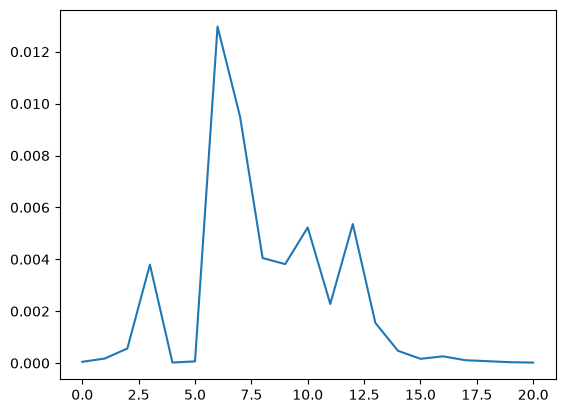

In [89]:
plt.plot(mps_scores)

In [90]:
overlaps = [l[-1] for l in triv_defect_results]

In [91]:
overlaps

[np.float32(0.99209046),
 np.float32(0.99901575),
 np.float32(0.9948313),
 np.float32(0.9519422),
 np.float32(0.9896606),
 np.float32(0.98902005),
 np.float32(0.9455125),
 np.float32(0.9479383),
 np.float32(0.8814473),
 np.float32(0.78682137),
 np.float32(0.38272256),
 np.float32(0.71800834),
 np.float32(0.9475606),
 np.float32(0.9720118),
 np.float32(0.98556596),
 np.float32(0.99239105),
 np.float32(0.9926712),
 np.float32(0.99505347),
 np.float32(0.9967701),
 np.float32(0.9973121),
 np.float32(0.9977803)]

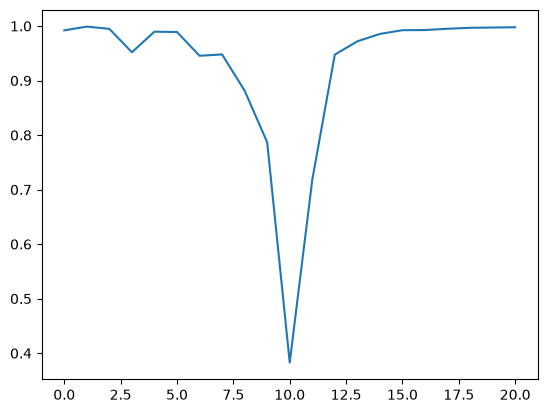

In [92]:
plt.plot(overlaps)

In [93]:
n1_indices = np.array([
    [l[3], l[4]]
    for l in triv_defect_results
])

In [94]:
np.round(n1_indices, 3)

array([[ 1.   +0.j,  1.   +0.j],
       [ 1.   +0.j,  1.   -0.j],
       [ 1.   -0.j,  1.   +0.j],
       [ 0.999-0.j,  0.998-0.j],
       [ 0.998+0.j,  0.999-0.j],
       [ 0.999+0.j,  0.999+0.j],
       [ 0.99 +0.j,  0.998-0.j],
       [ 0.986+0.j,  0.997+0.j],
       [ 0.989+0.j,  0.993+0.j],
       [ 0.982-0.j,  0.98 +0.j],
       [ 0.979+0.j,  0.985+0.j],
       [-0.992+0.j, -0.973-0.j],
       [ 0.63 -0.j, -0.992-0.j],
       [-0.553+0.j, -0.838+0.j],
       [-0.791+0.j, -0.172+0.j],
       [-0.991-0.j,  0.123+0.j],
       [-0.867+0.j, -0.079-0.j],
       [-0.997+0.j, -0.865+0.j],
       [-0.975+0.j, -0.998-0.j],
       [-0.991+0.j,  0.994-0.j],
       [-0.988+0.j, -0.444+0.j]])

In [95]:
cocyle_indices = np.array([
    [l[5], l[6]]
    for l in triv_defect_results
])

In [96]:
cocyle_indices

array([[ 0.99999996-1.09872239e-09j,  1.00000005-3.95626920e-10j],
       [ 0.99999989+6.16748377e-09j,  0.99999981+1.50971430e-10j],
       [ 1.00000034+4.28891928e-09j,  1.00000017-2.59693114e-10j],
       [ 0.99999986-7.92974153e-09j,  1.00000003+3.29616322e-08j],
       [ 0.99999959+6.80910439e-10j,  1.00000006-2.84127449e-09j],
       [ 0.99999994+5.91799443e-10j,  0.99999986-2.87872143e-10j],
       [ 1.00000002-2.66118805e-09j,  0.99999997-9.48363194e-09j],
       [ 0.99999981-9.63745389e-09j,  1.00000009-7.00030550e-09j],
       [ 0.99999997-1.99362533e-08j,  0.99999981+1.05986112e-09j],
       [ 0.99999994-2.82809425e-08j,  1.00000014-3.51039227e-09j],
       [ 1.00000003-6.36505045e-09j,  0.99999983-1.05050402e-07j],
       [-1.00000002+8.51340576e-09j, -1.00000008-2.37069271e-08j],
       [-1.00000003-2.13379622e-09j, -1.00000002+6.86071510e-09j],
       [-1.00000001-1.49186015e-08j, -1.00000001+1.94709428e-07j],
       [-1.        -6.54237600e-09j, -1.        +4.16896336e-0

In [97]:
np.round(cocyle_indices, 3)

array([[ 1.-0.j,  1.-0.j],
       [ 1.+0.j,  1.+0.j],
       [ 1.+0.j,  1.-0.j],
       [ 1.-0.j,  1.+0.j],
       [ 1.+0.j,  1.-0.j],
       [ 1.+0.j,  1.-0.j],
       [ 1.-0.j,  1.-0.j],
       [ 1.-0.j,  1.-0.j],
       [ 1.-0.j,  1.+0.j],
       [ 1.-0.j,  1.-0.j],
       [ 1.-0.j,  1.-0.j],
       [-1.+0.j, -1.-0.j],
       [-1.-0.j, -1.+0.j],
       [-1.-0.j, -1.+0.j],
       [-1.-0.j, -1.+0.j],
       [-1.-0.j, -1.+0.j],
       [-1.+0.j, -1.+0.j],
       [-1.+0.j, -1.-0.j],
       [-1.-0.j, -1.+0.j],
       [-1.+0.j, -1.-0.j],
       [-1.+0.j, -1.+0.j]])

### Nontrivial

In [98]:
mps_scores = [l[1][-1] for l in nontriv_opt_results]

In [99]:
mps_scores

[2.2530555725097656e-05,
 2.8312206268310547e-06,
 0.0001055598258972168,
 0.00010186433792114258,
 0.0002479851245880127,
 0.0004672706127166748,
 0.0009875595569610596,
 0.0019185245037078857,
 0.0037381350994110107,
 0.0063505470752716064,
 0.013803601264953613,
 0.006532818078994751,
 0.0035300850868225098,
 0.001819312572479248,
 0.0009203255176544189,
 0.00044411420822143555,
 0.0002161860466003418,
 0.00010648369789123535,
 0.0001310408115386963,
 1.2516975402832031e-06,
 2.6524066925048828e-05]

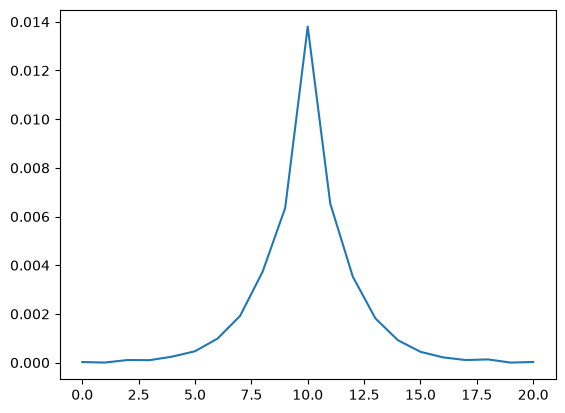

In [100]:
plt.plot(mps_scores)

In [101]:
n1_indices = np.array([
    [l[3], l[4]]
    for l in nontriv_defect_results
])

In [102]:
np.round(n1_indices, 3)

array([[-0.166+0.j,  0.985-0.j],
       [-1.   -0.j,  0.775-0.j],
       [-0.991-0.j, -1.   +0.j],
       [-0.445+0.j, -0.989-0.j],
       [-0.999-0.j,  0.723-0.j],
       [-0.999+0.j,  0.202-0.j],
       [-0.951+0.j, -0.988+0.j],
       [-0.982+0.j, -0.605+0.j],
       [-0.995+0.j, -0.677+0.j],
       [-0.946+0.j, -0.964+0.j],
       [-0.664+0.j,  0.265+0.j],
       [-0.976-0.j, -0.945-0.j],
       [ 0.251+0.j, -0.316-0.j],
       [-0.914-0.j, -0.165-0.j],
       [-0.976+0.j, -0.963+0.j],
       [-0.952-0.j, -0.98 +0.j],
       [-0.997+0.j, -0.277+0.j],
       [-0.823+0.j, -0.124+0.j],
       [-0.441+0.j, -0.77 +0.j],
       [-0.974-0.j, -0.065+0.j],
       [-0.898+0.j, -0.9  -0.j]])

In [103]:
cocyle_indices = np.array([
    [l[5], l[6]]
    for l in nontriv_defect_results
])

In [104]:
cocyle_indices

array([[-1.00000003-7.69353303e-10j, -0.99999999-2.09952222e-10j],
       [-1.00000002+3.04114944e-09j, -0.99999998-3.16611589e-08j],
       [-0.99999997+2.76234522e-08j, -0.99999999+5.01534370e-09j],
       [-1.        +1.25772093e-09j, -1.        -2.04486397e-08j],
       [-1.00000001-2.56969795e-09j, -1.00000004-5.97739802e-09j],
       [-0.99999998-3.65490738e-09j, -1.00000001+3.04651692e-08j],
       [-0.99999998-3.38497230e-10j, -0.99999999-4.16446981e-08j],
       [-1.00000005-1.18282441e-09j, -0.99999998+9.45002676e-09j],
       [-0.99999997+1.25591038e-09j, -1.00000002+1.30855238e-07j],
       [-0.99999999+1.83831676e-08j, -1.        +2.42890407e-08j],
       [-1.        -6.41779180e-09j, -0.99999995-5.76875746e-09j],
       [ 1.00000002-1.26703318e-08j,  0.99999997+2.18070358e-08j],
       [ 1.00000005+7.64678766e-09j,  1.00000001+1.40794618e-08j],
       [ 1.        -1.22036817e-09j,  1.        -8.42149804e-09j],
       [ 1.00000003+4.97922376e-09j,  1.        +4.53117643e-0

In [105]:
overlaps = [l[-1] for l in nontriv_defect_results]

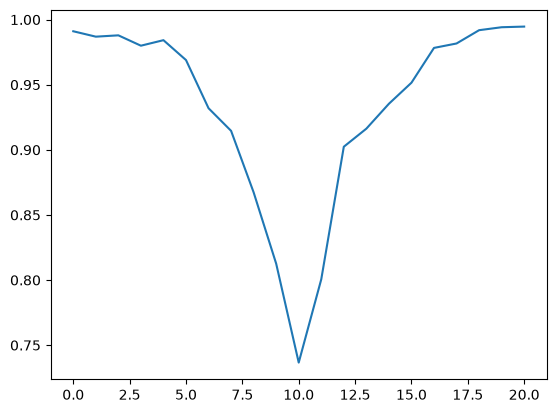

In [106]:
plt.plot(overlaps)